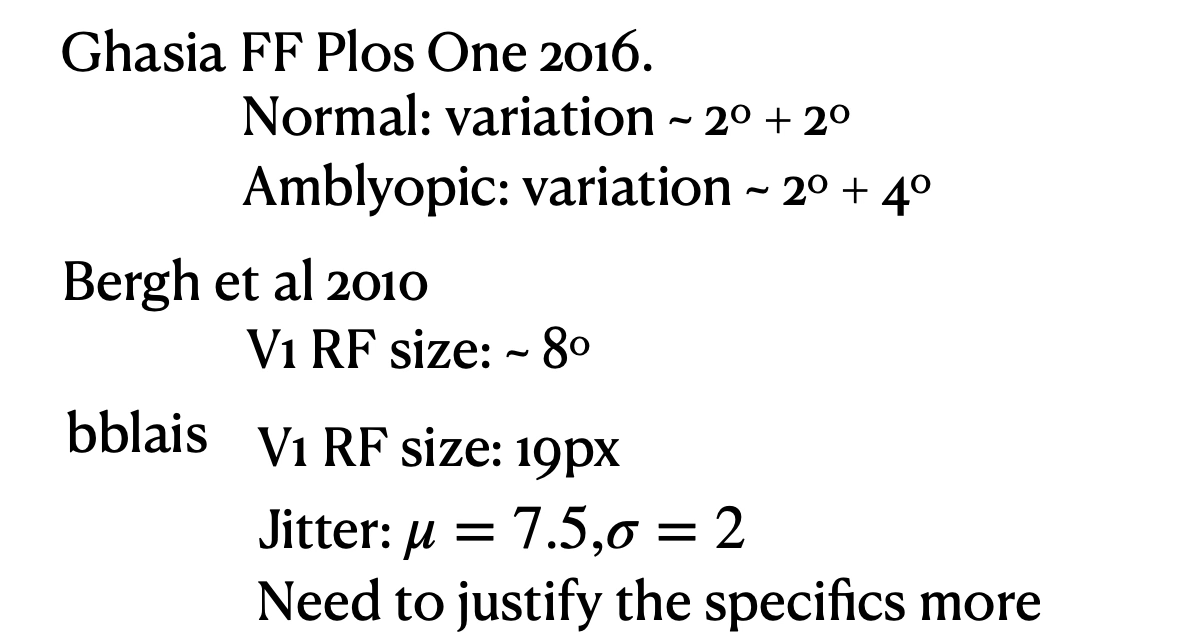

In [1]:
19/8

2.375

In [2]:
7.5/2

3.75

In [3]:
%matplotlib inline
from pylab import *

In [4]:
import process_images_hdf5 as pi5
import filters

In [5]:
from skimage import io, color
from skimage.transform import rescale,resize,rotate
import glob
import os
from tqdm.notebook import tqdm

70.0

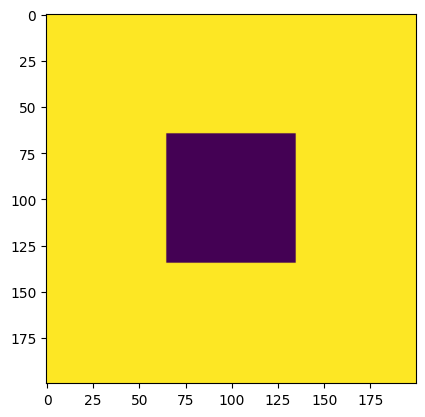

In [56]:
N=70
sz=200
arr=ones((sz,sz))
arr[sz//2-N//2:sz//2-N//2+N,sz//2-N//2:sz//2-N//2+N]=0
imshow(arr)
sqrt(sum(arr==0))

In [57]:
def dog(sd1,sd2,size):
    import numpy
    import scipy.signal as sig

    v1=numpy.floor((size-1.0)/2.0)
    v2=size-1-v1
    
    y,x=numpy.mgrid[-v1:v2,-v1:v2]
    
    pi=numpy.pi
    
    # raise divide by zero error if sd1=0 and sd2=0
    
    if sd1>0:
        g=1./(2*pi*sd1*sd1)*numpy.exp(-x**2/2/sd1**2 -y**2/2/sd1**2)
        if sd2>0:
            g=g- 1./(2*pi*sd2*sd2)*numpy.exp(-x**2/2/sd2**2 -y**2/2/sd2**2)
    else:
        g=- 1./(2*pi*sd2*sd2)*numpy.exp(-x**2/2/sd2**2 -y**2/2/sd2**2)
    
    return g

def dog_filter(A,sd1=1,sd2=3,size=None,shape='valid',surround_weight=1):
    import numpy
    import scipy.signal as sig

    if not size:
        size=2.0*numpy.ceil(2.0*max([sd1,sd2]))+1.0
        
    if sd1==0 and sd2==0:
        B=copy.copy(A)
        return B
    
    g=dog(sd1,sd2,size)
    g=g-g.mean()
    
    B=sig.convolve2d(A,g,mode=shape)
    
    return B


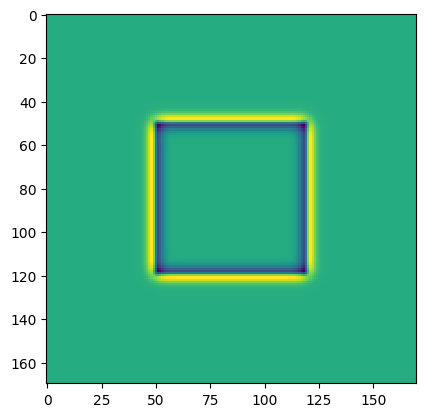

In [58]:
im2=dog_filter(arr,1,3,32,'valid')
imshow(im2,interpolation='nearest')

4

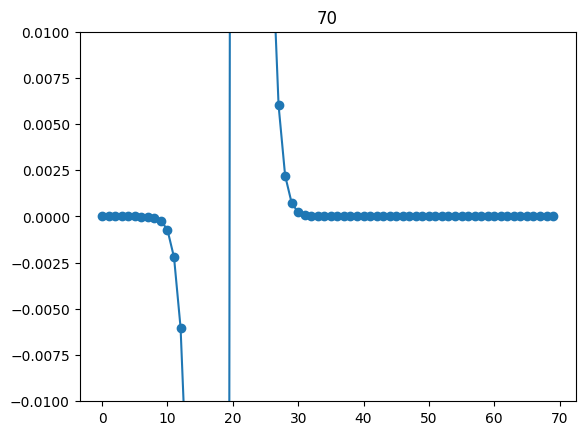

In [59]:
y=im2[sz//2,sz//2:]
plot(y,'-o')
ylim([-.01,.01])
title(N)
max(where(y==0)[0])

So at this size, a 19x19 RF will see only zeros.  Any smaller it will 

In [45]:
y

array([-8.15096091e-17, -8.15096091e-17, -8.15096091e-17, -8.15096091e-17,
       -8.15096091e-17, -8.15096091e-17, -8.15096091e-17, -8.15096091e-17,
       -8.15096091e-17, -8.15096091e-17, -8.15096091e-17, -8.15096091e-17,
       -8.15096091e-17, -8.15096091e-17, -8.15096091e-17, -8.15096091e-17,
       -8.15096091e-17, -8.15096091e-17, -8.15096091e-17, -8.15096091e-17,
       -8.15096091e-17, -8.15096091e-17, -8.15096091e-17, -8.15096091e-17,
       -8.15096091e-17, -8.15096091e-17, -8.15096091e-17, -8.15096091e-17,
       -8.15096091e-17, -8.15096091e-17,  5.09468886e-07,  3.00537947e-06,
        1.41428938e-05,  5.87668555e-05,  2.18870935e-04,  7.32977721e-04,
        2.21027411e-03,  6.00894922e-03,  1.47495910e-02,  3.27465838e-02,
        6.59041503e-02,  1.20440347e-01,  1.96665404e-01,  2.49157097e-01,
        1.32980768e-01, -1.32980768e-01, -2.49157097e-01, -1.96665404e-01,
       -1.20440347e-01, -6.59041503e-02, -3.27465838e-02, -1.47495910e-02,
       -6.00894922e-03, -